# Análise Comparativa entre Modelo Difuso de Lambert e Oren-Nayar Qualitativo

Este notebook tem como objetivo analisar e visualizar as diferenças físicas e matemáticas entre o modelo clássico de reflexão difusa de **Lambert** e o modelo microgeométrico de **Oren-Nayar** (versão qualitativa de 1994).

Para isso, foi realizada a renderização de uma esfera de vermelha áspera utilizando o renderizador  **PBRT-v4**, variando o parâmetro de rugosidade ($\sigma$).

In [1]:
import os

# Habilita suporte à leitura de arquivos OpenEXR no OpenCV
os.environ["OPENCV_IO_ENABLE_OPENEXR"] = "1"

import cv2
import numpy as np
import matplotlib.pyplot as plt
import imageio.v3 as iio
import subprocess

# Caminho para o executável do PBRT v4 instalado no WSL
PBRT_PATH = "/mnt/c/Users/Wemerson/pbrt-v4/build/pbrt"

# Conversão do caminho Windows (C:\\...) para o formato WSL (/mnt/c/...).
def windows_to_wsl(path):
    path = os.path.abspath(path)
    
    return (
        "/mnt/c" +
        path.replace("\\", "/")[2:]
    )

## Fundamentação Matemática do Modelo Oren-Nayar

Enquanto o modelo de Lambert assume que a luz é refletida isotropicamente em todas as direções de forma uniforme, a formulação qualitativa de Oren-Nayar introduz correções geométricas baseadas em microfacetas ásperas. 

Os coeficientes $A$ e $B$ controlam a atenuação e o ganho de brilho com base na rugosidade $\sigma$ (em radianos):

$$A = 1 - \frac{\sigma^2}{2(\sigma^2 + 0.33)}$$

$$B = \frac{0.45\sigma^2}{\sigma^2 + 0.09}$$

A função de distribuição de refletância bidirecional (BRDF) final é dada por:

$$f(w_o, w_i) = \frac{\rho}{\pi} \left( A + B \cdot \max(0, \cos(\phi_i - \phi_o)) \cdot \sin\alpha \cdot \tan\beta \right)$$

Onde:
* $\alpha$ é o máximo entre os ângulos de incidência e observação: $\max(\theta_i, \theta_o)$
* $\beta$ é o mínimo entre os ângulos de incidência e observação: $\min(\theta_i, \theta_o)$
* $\cos\phi_{\text{diff}}$ representa a diferença azimutal entre os vetores de luz e visão.

## Definição do Cenário de Teste (Template PBRT)

Para garantir uma comparação controlada e isolar o impacto do modelo de reflexão difusa, foi estruturada uma cena sintética otimizada para o **PBRT-v4**. 

O código abaixo define um template em string (`scene_template`) com marcadores dinâmicos (`{r}`, `{g}`, `{b}` e `{sigma_val}`) que serão injetados programaticamente durante os testes.

### Detalhes Técnicos da Cena:

* **Configuração de Câmera e Amostragem:** 
  * Câmera perspetiva com campo de visão (FOV) de $40^\circ$, posicionada de frente para a origem (`0 0 -5`).
  * Integrador do tipo *Path Tracing* limitado a um máximo de $5$ rebotes de luz (`maxdepth 5`).
  * Amostragem de alta qualidade via algoritmo de *Halton* com $64$ amostras por pixel (`pixelsamples 64`).
* **Iluminação de Área:** 
  * Uma fonte de luz esférica difusa posicionada levemente deslocada à direita e acima (`Translate 2 3 -2`) para gerar um gradiente de sombreamento suave na esfera, ideal para avaliar o caimento do shading (*shading rolloff*).
* **Fundo Controlado (Cinza Neutro):**
  * Uma parede de fundo posicionada atrás da esfera com reflectância puramente lambertiana de $0.5$ (cinza médio). Isso serve para isolar e validar a precisão matemática da nossa BRDF, garantindo que o plano de fundo se anule perfeitamente na operação de diferença.
* **Geometria de Teste:**
  * Uma esfera unitária de raio $1$ centralizada na origem, que recebe o material `"orennayar"` com parâmetros de reflectância RGB e rugosidade ($\sigma$) dinâmicos.

In [2]:
scene_template = """
# camera
LookAt 0 0 -5   0 0 0   0 1 0
Camera "perspective" "float fov" [40]

Sampler "halton" "integer pixelsamples" [64]
Integrator "path" "integer maxdepth" [5]

Film "rgb"
    "string filename" ["test_oren.exr"]
    "integer xresolution" [800]
    "integer yresolution" [800]

WorldBegin

# luz de área (boa pra ver shading)
AttributeBegin
    Translate 2 3 -2
    AreaLightSource "diffuse" "rgb L" [30 30 30]
    Shape "sphere" "float radius" [0.5]
AttributeEnd

# fundo cinza
AttributeBegin
    Translate 0 0 2
    Material "diffuse" "rgb reflectance" [0.5 0.5 0.5]

    Shape "trianglemesh"
        "integer indices" [0 1 2 0 2 3]
        "point3 P" [
            -5 -5 0
             5 -5 0
             5  5 0
            -5  5 0
        ]
AttributeEnd

# esfera com material Oren-Nayar calibrável
AttributeBegin
    MakeNamedMaterial "oren"
        "string type" "orennayar"
        "rgb reflectance" [{r} {g} {b}]
        "float sigma" [{sigma_val}]

    NamedMaterial "oren"
    Shape "sphere" "float radius" [1]
AttributeEnd
"""

## Pipeline de Renderização Automatizada

Para viabilizar a execução de múltiplos testes de forma programática, implementa-se uma função auxiliar responsável por gerenciar a geração do arquivo de cena, a execução do renderizador e a leitura dos dados de imagem resultantes. 

A função `render_test_oren` estabelece um fluxo automatizado dividido em quatro etapas principais:

### Etapas do Fluxo de Execução:

1. **Interpolação de Parâmetros:**
   * Os valores de reflectância RGB (`r, g, b`) e a rugosidade do material ($\sigma$) fornecidos como argumentos são injetados diretamente no template da cena (`scene_template`).

2. **Persistência Temporária em Disco:**
   * O conteúdo textual formatado é salvo temporariamente em um arquivo de cena física denominado `orennayar-test.pbrt`.

3. **Invocação do PBRT-v4 via Subprocesso:**
   * Utiliza-se a biblioteca `subprocess` para disparar a execução do executável do PBRT-v4. 
   * A chamada é encapsulada em um ambiente WSL (*Windows Subsystem for Linux*), garantindo a portabilidade e execução direta do renderizador a partir do ambiente do Jupyter Notebook.

4. **Leitura e Tratamento da Imagem Linear (HDR):**
   * A imagem de saída em formato de alta faixa dinâmica (`.exr`) é carregada utilizando a biblioteca OpenCV.
   * Utilizam-se as flags `IMREAD_ANYCOLOR` e `IMREAD_ANYDEPTH` para preservar a profundidade de bits flutuantes e a linearidade física dos dados (sem aplicação precoce de curvas de gama).
   * Realiza-se a conversão do espaço de cores padrão do OpenCV (BGR) para o padrão de exibição (RGB) antes de retornar a matriz de pixels para a memória do Python.

In [3]:
def render_test_oren(r=0.7, g=0.2, b=0.2, sigma=30.0):
    # 1. Substitui os parâmetros no template
    pbrt_content = scene_template.format(
        r=r,
        g=g,
        b=b,
        sigma_val=sigma
    )

    # 2. Salva o arquivo temporário
    filename = "orennayar-test.pbrt"
    with open(filename, "w") as f:
        f.write(pbrt_content)

    print(f"Renderizando com sigma={sigma} e cor=[{r}, {g}, {b}]...")

    # 3. Executa o PBRT
    scene_wsl = windows_to_wsl(filename)
    
    result = subprocess.run(
        ["wsl", PBRT_PATH, scene_wsl],
        capture_output=True,
        text=True
    )
    
    if result.returncode != 0:
        print(result.stderr)
        return None
        
    # 4. Lê a imagem EXR (linear)
    img_exr = cv2.imread(
        "test_oren.exr",
        cv2.IMREAD_ANYCOLOR | cv2.IMREAD_ANYDEPTH
    )

    img_rgb = cv2.cvtColor(img_exr, cv2.COLOR_BGR2RGB)

    # Retorna imagem linear
    return img_rgb    

## Função de Visualização para Imagens HDR

As imagens produzidas pelo PBRT-v4 são armazenadas em formato OpenEXR com radiância linear de alta faixa dinâmica (HDR). Para exibição em monitores convencionais, utiliza-se uma função que:

- aplica um operador simples de *tone mapping* $\left(L'=\frac{L}{1+L}\right)$ para comprimir a faixa dinâmica;
- realiza uma conversão aproximada do espaço linear para sRGB por meio de correção gama ($\gamma = 2.2$).

Esse procedimento produz uma representação visual mais adequada sem alterar os dados originais utilizados nas análises.

In [4]:
def show_exr(img):

    img_display = np.clip(img, 0, None)

    # tone mapping HDR
    img_display = img_display / (1 + img_display)

    # linear para sRGB
    img_display = img_display ** (1/2.2)

    return img_display

## Execução e Visualização dos Testes Comparativos

São renderizados dois casos representativos do modelo de Oren-Nayar:

- **Lambertiano Puro ($\sigma = 0^\circ$)**: corresponde ao caso limite em que o modelo se reduz à BRDF de Lambert.
- **Oren-Nayar Áspero ($\sigma = 60^\circ$)**: representa uma superfície com elevada rugosidade difusa, evidenciando os efeitos microgeométricos previstos pelo modelo.

As imagens são plotadas lado a lado para permitir a comparação visual do comportamento do sombreamento em ambas as condições.

Renderizando com sigma=0.0 e cor=[0.7, 0.2, 0.2]...
Renderizando com sigma=60.0 e cor=[0.7, 0.2, 0.2]...


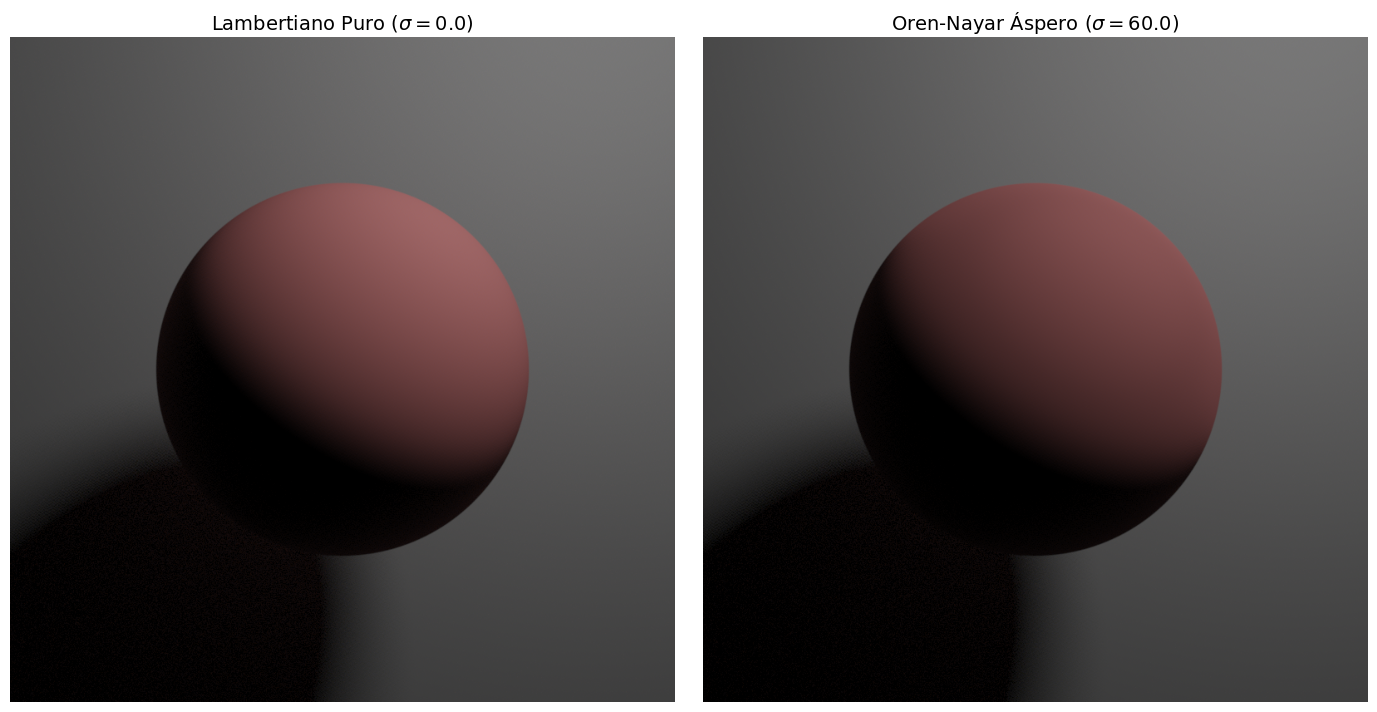

In [5]:
# Teste 1: Lambertiano Puro (Sigma = 0)
img_lambert = render_test_oren(
    r=0.7,
    g=0.2,
    b=0.2,
    sigma=0.0
)

# Teste 2: Oren-Nayar Áspero (Sigma = 60)
img_oren_60 = render_test_oren(
    r=0.7,
    g=0.2,
    b=0.2,
    sigma=60.0
)

# Exibição lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].imshow(show_exr(img_lambert))
axes[0].set_title(r"Lambertiano Puro ($\sigma = 0.0$)", fontsize=14)
axes[0].axis("off")

axes[1].imshow(show_exr(img_oren_60))
axes[1].set_title(r"Oren-Nayar Áspero ($\sigma = 60.0$)", fontsize=14)
axes[1].axis("off")

plt.tight_layout()
plt.show()

## Análise Espacial de Divergência e Assinatura Visual

Para avaliar com precisão matemática onde e como os dois modelos divergem fisicamente sobre a superfície esférica, realiza-se o cálculo da diferença absoluta pixel a pixel. Esse método isola as regiões de maior discrepância de sombreamento e revela o comportamento geométrico intrínseco de cada formulação.

### Metodologia de Processamento e Visualização:

* **Cálculo da Diferença Absoluta:**
  * O erro é calculado através do valor absoluto da subtração das matrizes de imagem: $|I_{\text{lambert}} - I_{\text{oren\_60}}|$. 
  * Essa operação garante que apenas a magnitude da diferença de radiância seja computada, resultando em um fundo perfeitamente nulo (preto) onde as imagens são idênticas (como no plano de fundo cinza da cena).
* **Diferença Absoluta Real (x1):**
  * Apresenta a escala real de energia divergente entre os modelos. Devido à sutileza física das mudanças de sombreamento, os valores numéricos são baixos nesta escala, o que pode limitar a percepção de detalhes sob condições normais de contraste.
* **Diferença Ampliada (x5):**
  * Aplica-se um fator multiplicativo de $5$ sobre a matriz de diferença para transladar os valores de erro para uma faixa dinâmica de maior contraste visual. 
  * Este procedimento visa evidenciar a "assinatura geométrica" da divergência matemática, destacando o padrão em formato de crescente (ou foice) localizado nas bordas de fuga e transição de penumbra da esfera, onde os efeitos de micro-rugosidade de Oren-Nayar atuam com maior intensidade.

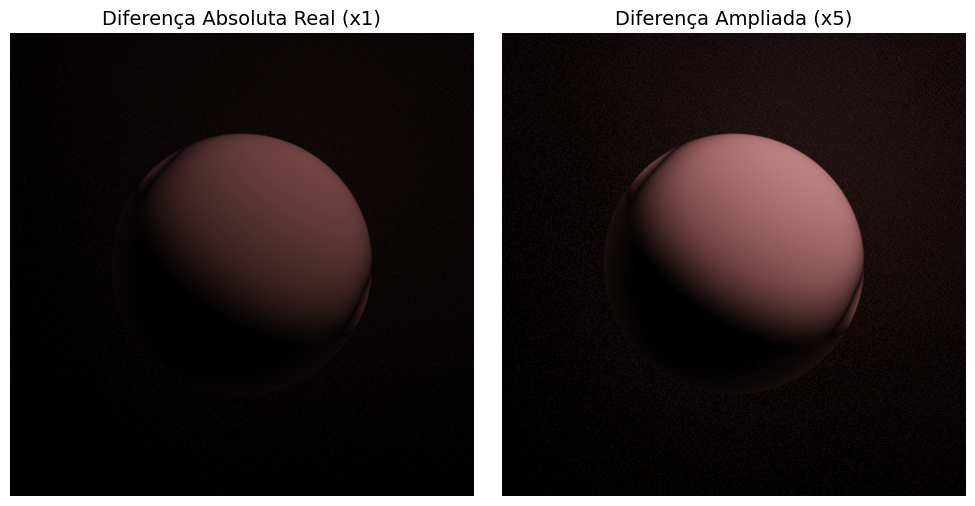

In [7]:
# Cálculo da Diferença
diferenca = np.abs(img_lambert - img_oren_60)

# Exibição Lado a Lado
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Diferença Real (x1) - Mostra a magnitude real do erro
axes[0].imshow(show_exr(diferenca))
axes[0].set_title("Diferença Absoluta Real (x1)", fontsize=14)
axes[0].axis("off")

# Diferença Ampliada (x5) - Destaca a assinatura visual do modelo
axes[1].imshow(show_exr(diferenca * 5))
axes[1].set_title("Diferença Ampliada (x5)", fontsize=14)
axes[1].axis("off")

plt.tight_layout()
plt.show()

## Análise dos Resultados e Discussão Física

A partir das renderizações e das imagens de diferença absoluta obtidas acima, podemos traçar importantes conclusões físicas sobre a implementação:

1. **Atenuação no Centro:** No modelo de Oren-Nayar ($\sigma = 60.0$), o coeficiente $A \approx 0.58$ atua diminuindo o brilho geral na região central da esfera em comparação com o Lambertiano Puro ($A = 1.0$). Isso simula a perda de energia devido ao sombreamento interno das microfendas.
2. **O Efeito de Borda (Retroespalhamento Qualitativo):** Na imagem **Diferença Ampliada (x5)**, observamos um formato de "crescente" ou "foice" vermelho brilhante na transição para a penumbra. 
   * Isso ocorre porque o termo $B \cdot \sin\alpha \cdot \tan\beta$ ganha força máxima em ângulos rasos ($\theta_i, \theta_o \to 90^\circ$).
   * A tangente do menor ângulo ($\tan\beta$) compensa matematicamente o decaimento rápido do cosseno da projeção de luz ($\cos\theta_i$).
   * Fisicamente, isso simula o fato de que as microfacetas da argila voltadas de frente para a luz continuam visíveis e brilhantes nas bordas, enquanto uma superfície Lambertiana (lisa) já teria escurecido completamente.
3. **Isolamento de Alterações:** O fundo perfeitamente preto na imagem de diferença comprova matematicamente a precisão do experimento, mostrando que apenas a física da esfera foi alterada (com o fundo Lambertiano idêntico de $0.5$ se anulando em $|0.5 - 0.5| = 0.0$).

## Estudo Paramétrico da Rugosidade ($\sigma$)

Para compreender a transição gradual entre o modelo ideal de Lambert e a formulação qualitativa de Oren-Nayar, realiza-se um estudo paramétrico com múltiplos valores de rugosidade. Essa abordagem analítica viabiliza a observação sistemática de como a distribuição de radiância se comporta em níveis intermediários de aspereza superficial sob a aproximação simplificada do modelo.

### Metodologia do Experimento:

* **Varredura Linear:**
  * O parâmetro de rugosidade ($\sigma$) é variado de forma incremental em passos de $15^\circ$, cobrindo o intervalo $[0.0^\circ, 60.0^\circ]$.
  * Mantêm-se os parâmetros de iluminação, posição de câmera e reflectância cromática constantes para garantir que as alterações sejam decorrentes exclusivamente da variação da rugosidade teórica.
* **Pipeline de Renderização:**
  * O processo executa um loop que reescreve temporariamente o arquivo de cena do PBRT-v4, dispara o renderizador e armazena os arrays de imagem em um dicionário indexado pelo valor correspondente de $\sigma$.

Renderizando com sigma=0.0 e cor=[0.7, 0.2, 0.2]...
Renderizando com sigma=15.0 e cor=[0.7, 0.2, 0.2]...
Renderizando com sigma=30.0 e cor=[0.7, 0.2, 0.2]...
Renderizando com sigma=45.0 e cor=[0.7, 0.2, 0.2]...
Renderizando com sigma=60.0 e cor=[0.7, 0.2, 0.2]...


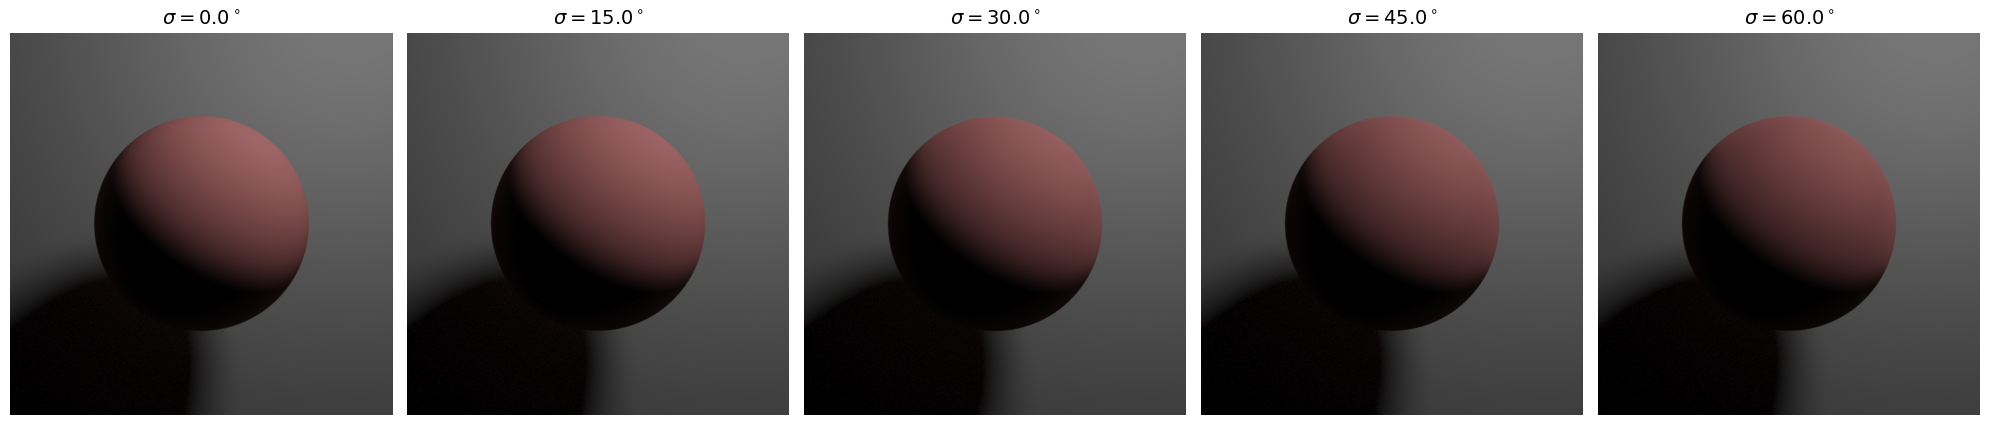

In [8]:
# 1. Definição dos valores de sigma para testar
valores_sigma = [0.0, 15.0, 30.0, 45.0, 60.0]
imagens_sigma = {}

# 2. Renderizações em lote
for s in valores_sigma:
    imagens_sigma[s] = render_test_oren(
        r=0.7,
        g=0.2,
        b=0.2,
        sigma=s
    )

# 3. Painel comparativo
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, s in enumerate(valores_sigma):
    axes[i].imshow(show_exr(imagens_sigma[s]))
    axes[i].set_title(fr"$\sigma = {s}^\circ$", fontsize=14)
    axes[i].axis("off")

plt.tight_layout()
plt.show()